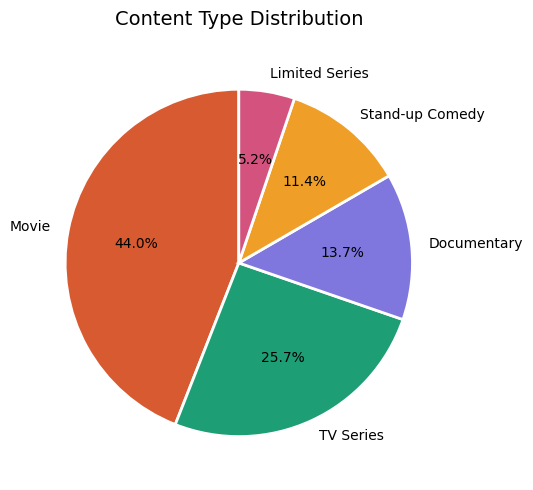

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_clean = pd.read_csv('../data/netflix_clean.csv')

fig, ax = plt.subplots(figsize=(7, 5))
content_counts = df_clean['content_type'].value_counts()
colors = ['#D85A30','#1D9E75','#7F77DD','#EF9F27','#D4537E']
ax.pie(content_counts.values, labels=content_counts.index,
       autopct='%1.1f%%', colors=colors, startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Content Type Distribution', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../charts/01_content_type.png', dpi=150, bbox_inches='tight')
plt.show()

"Movies dominate Netflix's catalog — but TV Shows drive more engagement due to multi-episode format."

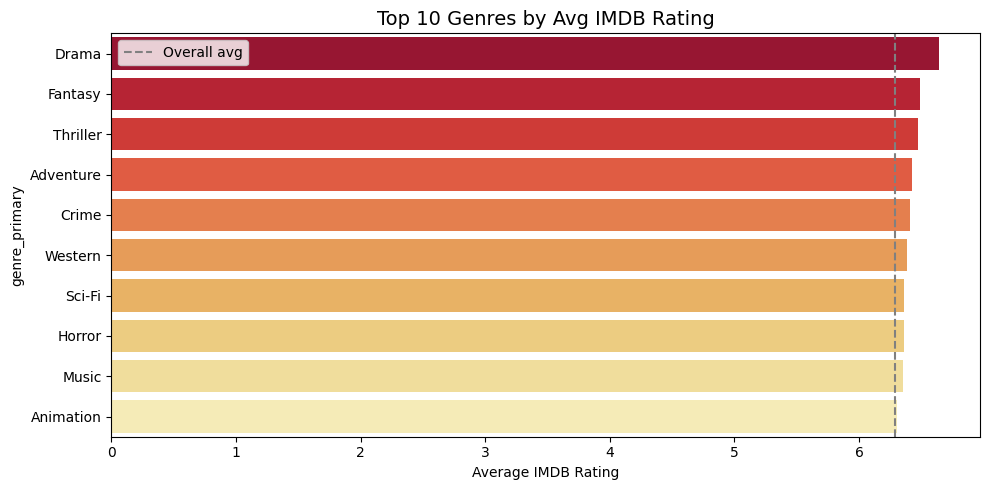

In [18]:
import seaborn as sns
genre_rating = df_clean.groupby('genre_primary')['imdb_rating'] \
                       .mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=genre_rating.values, y=genre_rating.index,
            hue=genre_rating.index, legend=False,
            palette='YlOrRd_r', ax=ax)
ax.set_title('Top 10 Genres by Avg IMDB Rating', fontsize=14)
ax.set_xlabel('Average IMDB Rating')
ax.axvline(df_clean['imdb_rating'].mean(), color='gray',
           linestyle='--', label='Overall avg')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/02_genre_rating.png', dpi=150, bbox_inches='tight')
plt.show()

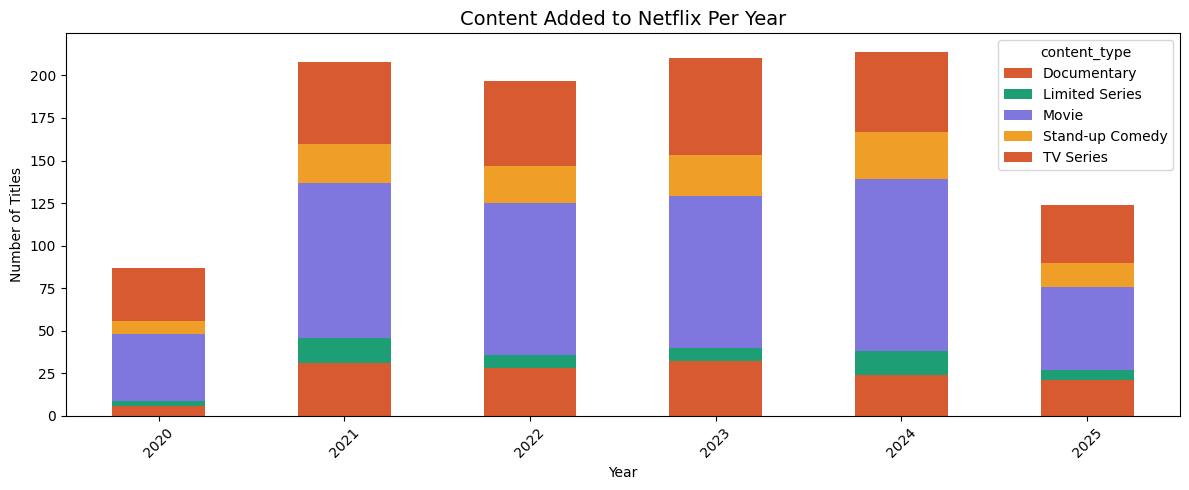

In [19]:
yearly = df_clean.groupby(['added_year','content_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
yearly.plot(kind='bar', stacked=True, ax=ax,
            color=['#D85A30','#1D9E75','#7F77DD','#EF9F27'])
ax.set_title('Content Added to Netflix Per Year', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../charts/03_content_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

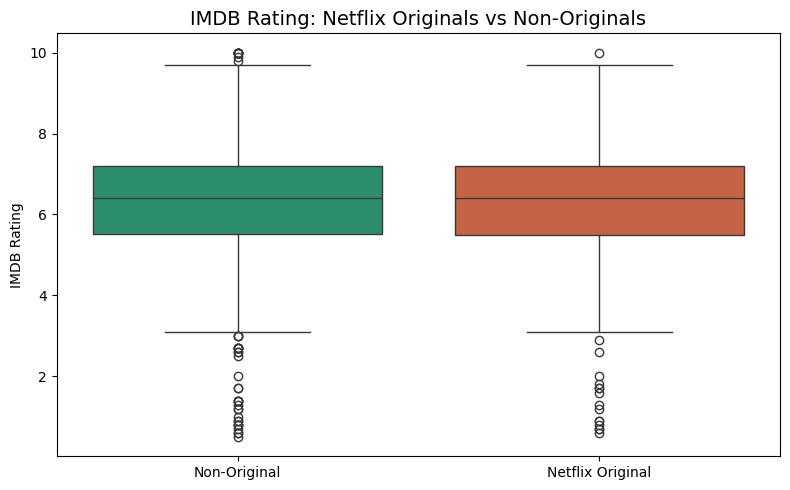

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
df_clean['Original'] = df_clean['is_netflix_original'].map(
    {True:'Netflix Original', False:'Non-Original'})
sns.boxplot(data=df_clean, x='Original', y='imdb_rating',
            hue='Original', legend=False,
            palette={'Netflix Original':'#D85A30','Non-Original':'#1D9E75'}, ax=ax)
ax.set_title('IMDB Rating: Netflix Originals vs Non-Originals', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('IMDB Rating')
plt.tight_layout()
plt.savefig('../charts/04_originals_vs_nonoriginals.png', dpi=150, bbox_inches='tight')
plt.show()

Netflix Originals show slightly lower median IMDB ratings — quantity over quality strategy?

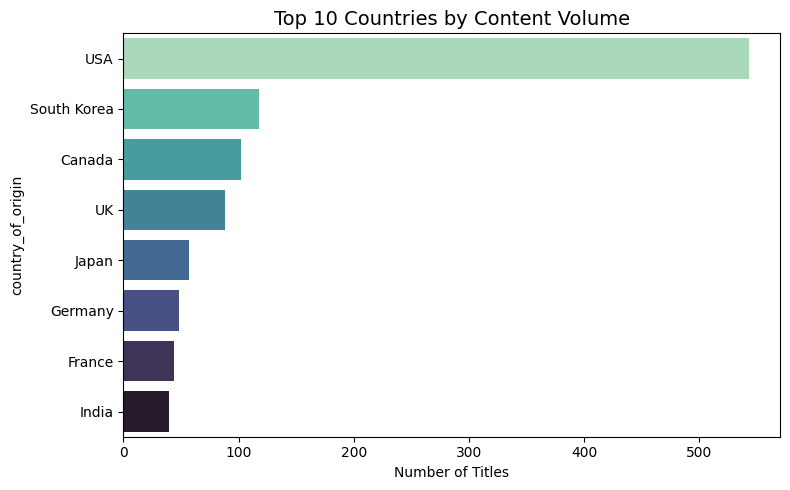

In [21]:
top_countries = df_clean['country_of_origin'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_countries.values, y=top_countries.index,
            hue=top_countries.index, legend=False,
            palette='mako_r', ax=ax)
ax.set_title('Top 10 Countries by Content Volume', fontsize=14)
ax.set_xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('../charts/05_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()

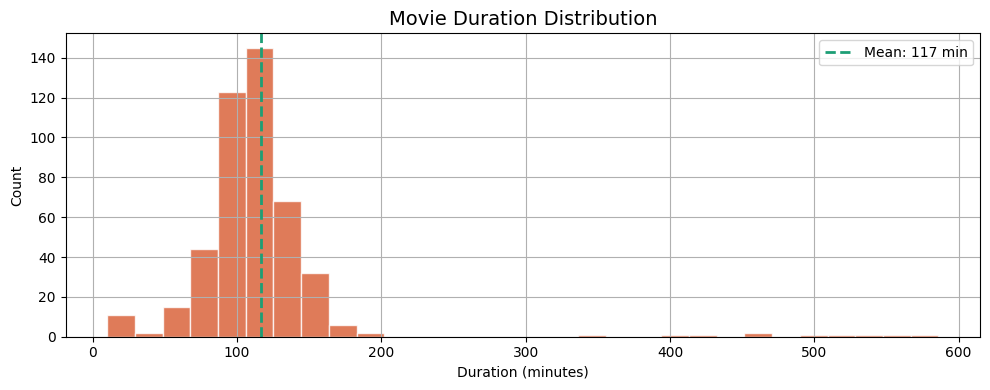

In [22]:
movies_only = df_clean[df_clean['content_type']=='Movie']

fig, ax = plt.subplots(figsize=(10, 4))
movies_only['duration_minutes'].hist(bins=30, ax=ax,
    color='#D85A30', edgecolor='white', alpha=0.8)
ax.axvline(movies_only['duration_minutes'].mean(),
           color='#1D9E75', linestyle='--', linewidth=2,
           label=f"Mean: {movies_only['duration_minutes'].mean():.0f} min")
ax.set_title('Movie Duration Distribution', fontsize=14)
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/06_duration_dist.png', dpi=150, bbox_inches='tight')
plt.show()

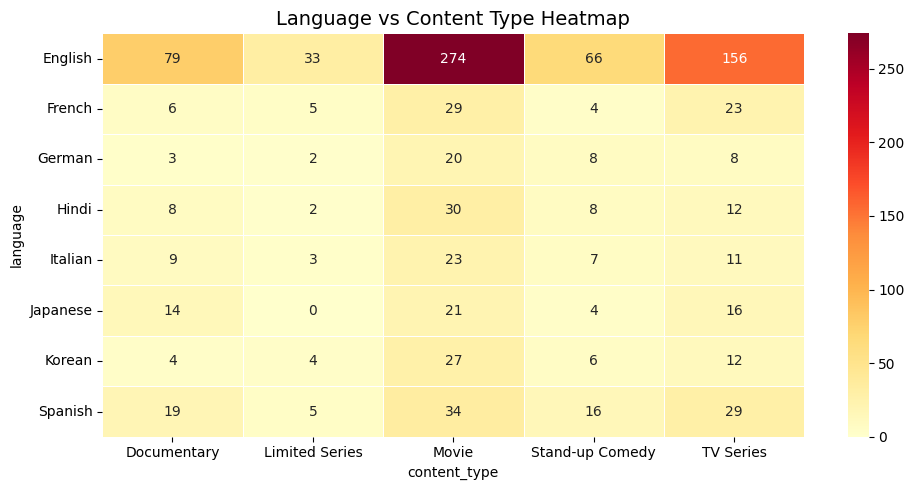

In [23]:
top_langs = df_clean['language'].value_counts().head(8).index
lang_df = df_clean[df_clean['language'].isin(top_langs)]
pivot = lang_df.groupby(['language','content_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Language vs Content Type Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../charts/07_language_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()